In [9]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Get loftee_hc significant appv correlations

In [2]:
# Configuration and paths
corr_method = 'pearson'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
appv = pl.read_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6coding_PRScorr.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [14]:
plof_cons = [
    'consequence_stop_gained',
    'consequence_frameshift_variant',
    'consequence_splice_acceptor_variant',
    'consequence_splice_donor_variant',
    'consequence_start_lost',
    'consequence_stop_lost',
]

alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc'] + plof_cons).with_columns(
    is_plof = pl.sum_horizontal(plof_cons)
).select(['id', 'region', 'loftee_hc', 'is_plof'])
alof

id,region,loftee_hc,is_plof
str,str,i8,i64
"""chr1:169795116:G:C""","""ENSG00000000460""",0,1
"""chr1:169798959:G:A""","""ENSG00000000460""",0,1
"""chr1:169798959:G:C""","""ENSG00000000460""",0,1
"""chr1:169798959:G:GT""","""ENSG00000000460""",0,1
"""chr1:169798959:G:T""","""ENSG00000000460""",0,1
…,…,…,…
"""chr7:151061966:C:T""","""ENSG00000288608""",0,0
"""chr7:151061967:GA:G""","""ENSG00000288608""",1,1
"""chr7:151061968:A:G""","""ENSG00000288608""",0,0


In [15]:
alof['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000143631""",9263
"""ENSG00000008710""",8573
"""ENSG00000081853""",8384
"""ENSG00000178209""",8265
"""ENSG00000151914""",7460
…,…
"""ENSG00000072694""",73
"""ENSG00000164032""",67
"""ENSG00000162188""",59


In [16]:
gnames = pl.read_csv('/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
    separator='\t',
    null_values=['.', 'NA'],
).filter(
    pl.col('transcript_type') == 'protein_coding'
).select(['gene', 'gene_id']).unique().rename({
    'gene': 'gene_name',
    'gene_id': 'region'
}).drop_nulls()

gnames

gene_name,region
str,str
"""TM9SF3""","""ENSG00000077147"""
"""ZFP69B""","""ENSG00000187801"""
"""NIPAL1""","""ENSG00000163293"""
"""EIF2A""","""ENSG00000144895"""
"""HOOK1""","""ENSG00000134709"""
…,…
"""PIK3C3""","""ENSG00000078142"""
"""DNAJC16""","""ENSG00000116138"""
"""ST20""","""ENSG00000180953"""


In [17]:
alof_gp = appv.join(alof, on='id', how='inner').join(gnames, on='region', how='left').sort('n_individuals', descending=True)
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,is_plof,gene_name
str,str,u32,f32,f32,str,i8,i64,str
"""chr1:1793247:C:T""","""heel_bone_mineral_density_bmd_…",759,0.004783,0.877477,"""ENSG00000078369""",0,0,"""GNB1"""
"""chr1:17354601:G:A""","""age_started_wearing_glasses_or…",759,-0.011846,0.987002,"""ENSG00000159339""",0,0,"""PADI4"""
"""chr1:20350923:C:T""","""hdl_cholesterol_int""",759,-0.03964,0.82771,"""ENSG00000158816""",0,0,"""VWA5B1"""
"""chr1:20350923:C:T""","""calcium_int""",759,-0.051629,0.969885,"""ENSG00000158816""",0,0,"""VWA5B1"""
"""chr1:20350923:C:T""","""albumin_int""",759,-0.01811,0.90053,"""ENSG00000158816""",0,0,"""VWA5B1"""
…,…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,0,"""PLXNB2"""


In [18]:
top_var_counts = (
    alof_gp
    # .filter(pl.col('loftee_hc') == 1)
    .filter(pl.col('is_plof') == 1)
    .lazy()
    .group_by(["region", "gene_name", "phenotype", "id"])
    .agg(pl.col('n_individuals').sum().alias("top_plof_var_count"))
    .sort("top_plof_var_count", descending=True)
    .group_by(["region", "gene_name", "phenotype"], maintain_order=True)
    .first()
    .rename({"id": "top_plof_var"})
    .collect(engine='streaming')
)
top_var_counts

region,gene_name,phenotype,top_plof_var,top_plof_var_count
str,str,str,str,u32
"""ENSG00000157992""","""KRTCAP3""","""apolipoprotein_a_int""","""chr2:27442740:ATC:A""",759
"""ENSG00000162722""","""TRIM58""","""fathers_age_at_death_int""","""chr1:247857547:G:T""",759
"""ENSG00000182179""","""UBA7""","""shbg_int""","""chr3:49808978:A:AT""",759
"""ENSG00000106819""","""ASPN""","""calcium_int""","""chr9:92459666:A:AT""",759
"""ENSG00000143942""","""CHAC2""","""pulse_rate_automated_reading_i…","""chr2:53767980:TTC:T""",758
…,…,…,…,…
"""ENSG00000096746""","""HNRNPH3""","""age_at_hysterectomy_int""","""chr10:68339482:C:G""",1
"""ENSG00000077147""","""TM9SF3""","""heel_bone_mineral_density_bmd_…","""chr10:96559717:TCTGA:T""",1
"""ENSG00000077147""","""TM9SF3""","""pulse_rate_int""","""chr10:96559717:TCTGA:T""",1


In [20]:
# 1. Aggregate to get correlation (r) and number of pairs (n)
lofcorr_df = (
    alof_gp.lazy()
    .group_by(["region", "gene_name", "phenotype"])
    .agg(
        n_variants_nonull = (pl.col("mean_pheno_value").is_not_null() & pl.col("loftee_hc").is_not_null()).sum(),
        # n_individuals = pl.col("n_individuals").sum(),

        n_loftee_variants = pl.col("loftee_hc").sum(),
        loftee_corr = pl.corr("mean_pheno_value", "loftee_hc"),
        n_individuals_loftee = pl.col("n_individuals").filter(pl.col("loftee_hc") == 1),

        n_plof_variants = pl.col("is_plof").sum(),
        plof_corr = pl.corr("mean_pheno_value", "is_plof"),
        n_individuals_plof = pl.col("n_individuals").filter(pl.col("is_plof") == 1),
    )
    .join(top_var_counts.lazy(), on=["region", "gene_name", "phenotype"], how="left")
    .filter(
        (pl.col("n_variants_nonull") > 2) &
        (pl.col("n_plof_variants") > 0)
    )  
    
    # 2. Compute the t-statistic and p-value on the aggregated results
    .with_columns(
        plof_prop = (pl.col('n_plof_variants')/pl.col('n_variants_nonull')),
        # Calculate the t-statistic from r and n
        t_stat = pl.col("plof_corr") * ((pl.col("n_variants_nonull") - 2) / (1 - pl.col("plof_corr")**2))**0.5,
    )
    .with_columns(
        # Calculate the two-tailed p-value from the t-statistic
        corr_pval = pl.struct(["t_stat", "n_variants_nonull"]).map_elements(
            lambda x: (
                stats.t.sf(np.abs(x["t_stat"]), df=x["n_variants_nonull"] - 2) * 2
                if x["t_stat"] is not None else None
            ),
            return_dtype=pl.Float64
        )
    )
).collect()
# ).collect(engine='streaming')

# lofcorr_df.write_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")
lofcorr_df

region,gene_name,phenotype,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval
str,str,str,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64
"""ENSG00000270379""","""HEATR9""","""leg_fatfree_mass_left_int""",465,39,-0.081651,"[499, 39, … 1]",48,-0.053346,"[499, 39, … 1]","""chr17:35864811:G:A""",499,0.103226,-1.149496,0.250945
"""ENSG00000173442""","""EHBP1L1""","""haemoglobin_concentration_int""",1305,126,-0.016767,"[198, 130, … 1]",128,-0.021338,"[198, 130, … 1]","""chr11:65583128:TG:T""",198,0.098084,-0.770425,0.441188
"""ENSG00000127863""","""TNFRSF19""","""trunk_fat_mass_int""",332,13,0.141116,"[3, 2, … 1]",15,0.193154,"[5, 3, … 1]","""chr13:23570849:G:A""",5,0.045181,3.576164,0.000401
"""ENSG00000140691""","""ARMC5""","""mean_time_to_correctly_identif…",894,37,-0.028927,"[12, 8, … 1]",38,-0.020804,"[12, 8, … 1]","""chr16:31466375:CG:C""",12,0.042506,-0.621471,0.534449
"""ENSG00000137692""","""DCUN1D5""","""aspartate_aminotransferase_int""",99,6,0.048724,"[4, 1, … 1]",7,-0.049038,"[4, 1, … 1]","""chr11:103064370:TTTGA:T""",4,0.070707,-0.483546,0.629798
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000123213""","""NLN""","""lymphocyte_percentage_int""",532,53,0.073756,"[64, 32, … 1]",58,0.055806,"[64, 32, … 1]","""chr5:65788159:C:T""",64,0.109023,1.286754,0.198742
"""ENSG00000165118""","""C9orf64""","""eosinophill_percentage_int""",232,22,-0.06257,"[35, 28, … 1]",24,-0.028444,"[35, 28, … 1]","""chr9:83944965:G:A""",35,0.103448,-0.431543,0.666478
"""ENSG00000196700""","""ZNF512B""","""weight_impedance_int""",712,21,0.129488,"[54, 9, … 1]",24,0.132106,"[54, 9, … 1]","""chr20:63963824:CGA:C""",54,0.033708,3.551186,0.000409


In [ ]:
# lofcorr_df.write_parquet("/home/dnanexus/data_dir/association_files/is_plof_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

## Compare gene-phenotype associations between burden-test and correlation

### Compare directions

In [22]:
# lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/is_plof_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

lofcorr_df

region,gene_name,phenotype,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval
str,str,str,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64
"""ENSG00000270379""","""HEATR9""","""leg_fatfree_mass_left_int""",465,39,-0.081651,"[499, 39, … 1]",48,-0.053346,"[499, 39, … 1]","""chr17:35864811:G:A""",499,0.103226,-1.149496,0.250945
"""ENSG00000173442""","""EHBP1L1""","""haemoglobin_concentration_int""",1305,126,-0.016767,"[198, 130, … 1]",128,-0.021338,"[198, 130, … 1]","""chr11:65583128:TG:T""",198,0.098084,-0.770425,0.441188
"""ENSG00000127863""","""TNFRSF19""","""trunk_fat_mass_int""",332,13,0.141116,"[3, 2, … 1]",15,0.193154,"[5, 3, … 1]","""chr13:23570849:G:A""",5,0.045181,3.576164,0.000401
"""ENSG00000140691""","""ARMC5""","""mean_time_to_correctly_identif…",894,37,-0.028927,"[12, 8, … 1]",38,-0.020804,"[12, 8, … 1]","""chr16:31466375:CG:C""",12,0.042506,-0.621471,0.534449
"""ENSG00000137692""","""DCUN1D5""","""aspartate_aminotransferase_int""",99,6,0.048724,"[4, 1, … 1]",7,-0.049038,"[4, 1, … 1]","""chr11:103064370:TTTGA:T""",4,0.070707,-0.483546,0.629798
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000123213""","""NLN""","""lymphocyte_percentage_int""",532,53,0.073756,"[64, 32, … 1]",58,0.055806,"[64, 32, … 1]","""chr5:65788159:C:T""",64,0.109023,1.286754,0.198742
"""ENSG00000165118""","""C9orf64""","""eosinophill_percentage_int""",232,22,-0.06257,"[35, 28, … 1]",24,-0.028444,"[35, 28, … 1]","""chr9:83944965:G:A""",35,0.103448,-0.431543,0.666478
"""ENSG00000196700""","""ZNF512B""","""weight_impedance_int""",712,21,0.129488,"[54, 9, … 1]",24,0.132106,"[54, 9, … 1]","""chr20:63963824:CGA:C""",54,0.033708,3.551186,0.000409


In [34]:
lofcorr_df['region'].n_unique()

1960

In [ ]:
# Read the full Genebass results
# p-value thresholds
# pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# # Convert the pandas operations into a single Polars expression
# gb_pl = (
#     pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
#     .with_columns(
#         significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
#         phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
#         region = pl.col('gene_id'),
#         gene_name = pl.col('gene_symbol'),
#     )
#     .filter(
#         (pl.col('significant') == True) &
#         (pl.col('trait_type') == 'continuous') &
#         # (pl.col('annotation').str.contains('pLoF'))
#         (pl.col('annotation')=='pLoF')
#     )
#     .select(['region', 'gene_name', 'phenotype', 'trait_type', 'annotation', 'Pvalue', 'Pvalue_Burden'])
#     .unique()
# )

# Get minimum p-value per gene-phenotype pair
# gb_pl = (
#     gb_pl
#     .group_by(['region', 'gene_name', 'phenotype', 'trait_type'])
#     .agg([
#         pl.col("Pvalue").min().alias("min_pvalue_skato"),
#         pl.col("Pvalue_Burden").min().alias("min_pvalue_burden"),
#         pl.count().alias("n_annotations")  # how many rows contributed (may be 1)
#     ])
#     .sort("min_pvalue_skato")
# )

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).with_columns(
    p_adj_bonf = pl.min_horizontal(pl.col('rvat_pval') * plof['gene_id'].n_unique(), 1)
).filter(
    (pl.col('trait_type') == 'quantitative')
)

plof

# Join genebasss results with is_plof RVAT correlations
# gb_plof = gb_pl.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner')
# gb_plof = gb_plof.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
#     (pl.col('loftee_corr')*pl.col('beta') > 0).alias('sign_agreement'),
# )
# gb_plof

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64
"""OR4F5""",1,"""ENSG00000186092""",0.000113,357443,-0.022992,0.0632065,0.132324,0.145066,"""arm_fatfree_mass_right""","""quantitative""",false,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000186092""",0.716035,1.0
"""SAMD11""",1,"""ENSG00000187634""",0.000597,357443,0.0184458,0.027542,0.448545,0.298409,"""arm_fatfree_mass_right""","""quantitative""",false,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000187634""",0.503027,1.0
"""NOC2L""",1,"""ENSG00000188976""",0.000936,357443,-0.03701,0.0220121,2.82691,1.03294,"""arm_fatfree_mass_right""","""quantitative""",false,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000188976""",0.092696,1.0
"""KLHL17""",1,"""ENSG00000187961""",0.000554,357443,0.0273806,0.0286,0.916548,0.470591,"""arm_fatfree_mass_right""","""quantitative""",false,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000187961""",0.338383,1.0
"""PLEKHN1""",1,"""ENSG00000187583""",0.000474,357443,0.0396605,0.0309082,1.64653,0.700206,"""arm_fatfree_mass_right""","""quantitative""",false,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000187583""",0.199432,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MRPL41""",9,"""ENSG00000182154""",0.000092,114532,-0.162662,0.20283,0.643139,0.374095,"""heel_bone_mineral_density_bmd_…","""quantitative""",false,16041,false,"""heel_bone_mineral_density_bmd_…","""ENSG00000182154""",0.422576,1.0
"""DPH7""",9,"""ENSG00000148399""",0.000336,114532,-0.086658,0.105921,0.669349,0.383757,"""heel_bone_mineral_density_bmd_…","""quantitative""",false,16041,false,"""heel_bone_mineral_density_bmd_…","""ENSG00000148399""",0.413279,1.0
"""ARRDC1""",9,"""ENSG00000197070""",0.00031,114532,-0.041485,0.110302,0.141453,0.150678,"""heel_bone_mineral_density_bmd_…","""quantitative""",false,16041,false,"""heel_bone_mineral_density_bmd_…","""ENSG00000197070""",0.706841,1.0


In [57]:
gb_plof = plof.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='inner').with_columns(
    corr_p_adj_bonf = pl.min_horizontal(pl.col('corr_pval') * plof['gene_id'].n_unique(), 1),
    sign_agreement = pl.col('loftee_corr')*pl.col('beta') > 0,
).with_columns(
    corr_nom_signif = pl.col('corr_pval')<0.05,
    corr_bonf_signif = pl.col('corr_p_adj_bonf')<0.05,
).filter(pl.col('p_adj_bonf')<0.05)

gb_plof

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,corr_p_adj_bonf,sign_agreement,corr_nom_signif,corr_bonf_signif
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64,f64,bool,bool,bool
"""PAPPA2""",1,"""ENSG00000116183""",0.000339,357443,-0.195409,0.0365758,28.5431,7.03793,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000116183""",9.1637e-8,0.001592,1280,70,-0.129833,"[62, 54, … 1]",72,-0.127063,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.05625,-4.579527,0.000005,0.088863,true,true,false
"""CNPY2""",12,"""ENSG00000257727""",0.000194,357443,-0.238033,0.0481651,24.4236,6.11174,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000257727""",7.7314e-7,0.013432,141,19,-0.135488,"[56, 18, … 1]",21,-0.118148,"[56, 18, … 1]","""chr12:56315128:ACCTCCACAGT:A""",56,0.148936,-1.402774,0.162914,1.0,true,false,false
"""ACAN""",15,"""ENSG00000157766""",0.000101,357443,-0.436618,0.0667331,42.8076,10.219,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000157766""",6.0395e-11,0.000001,2030,55,-0.199516,"[40, 37, … 1]",58,-0.195695,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.028571,-8.986531,5.6937e-19,9.8917e-15,true,true,true
"""IGF1R""",15,"""ENSG00000140443""",0.000081,357443,-0.412619,0.0743493,30.7996,7.54349,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000140443""",2.8609e-8,0.000497,1093,46,-0.154286,"[13, 7, … 1]",48,-0.158062,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.043916,-5.287289,1.4990e-7,0.002604,true,true,true
"""G6PC1""",17,"""ENSG00000131482""",0.000904,357443,-0.110167,0.0223225,24.3567,6.09665,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000131482""",8.0048e-7,0.013907,268,24,0.030656,"[291, 180, … 1]",27,0.024152,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.100746,0.394017,0.693884,1.0,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""RHAG""",6,"""ENSG00000112077""",0.000249,347730,0.952411,0.070604,181.966,40.7438,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000112077""",1.8038e-41,3.1338e-37,315,16,0.174576,"[149, 5, … 1]",16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,1.0,true,true,false
"""ANK1""",8,"""ENSG00000029534""",0.000115,347730,0.656849,0.103458,40.3089,9.66391,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000029534""",2.1682e-10,0.000004,1392,34,0.269449,"[18, 12, … 1]",36,0.260112,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.025862,10.043396,5.8301e-23,1.0129e-18,true,true,true
"""VPS13A""",9,"""ENSG00000197969""",0.001064,347730,0.176348,0.0339876,26.9216,6.67392,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000197969""",2.1188e-7,0.003681,2047,225,0.035972,"[109, 67, … 1]",228,0.037607,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.111383,1.70186,0.088934,1.0,true,false,false


In [62]:
gb_plof.filter(
    (pl.col('corr_pval')<0.05) & 
    (pl.col('sign_agreement')==1)
)

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,corr_p_adj_bonf,sign_agreement,corr_nom_signif,corr_bonf_signif
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64,f64,bool,bool,bool
"""PAPPA2""",1,"""ENSG00000116183""",0.000339,357443,-0.195409,0.0365758,28.5431,7.03793,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000116183""",9.1637e-8,0.001592,1280,70,-0.129833,"[62, 54, … 1]",72,-0.127063,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.05625,-4.579527,0.000005,0.088863,true,true,false
"""ACAN""",15,"""ENSG00000157766""",0.000101,357443,-0.436618,0.0667331,42.8076,10.219,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000157766""",6.0395e-11,0.000001,2030,55,-0.199516,"[40, 37, … 1]",58,-0.195695,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.028571,-8.986531,5.6937e-19,9.8917e-15,true,true,true
"""IGF1R""",15,"""ENSG00000140443""",0.000081,357443,-0.412619,0.0743493,30.7996,7.54349,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000140443""",2.8609e-8,0.000497,1093,46,-0.154286,"[13, 7, … 1]",48,-0.158062,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.043916,-5.287289,1.4990e-7,0.002604,true,true,true
"""MC4R""",18,"""ENSG00000166603""",0.000214,357443,0.255292,0.0457938,31.0786,7.60591,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000166603""",2.4779e-8,0.00043,246,16,0.238696,"[45, 25, … 1]",18,0.189241,"[45, 25, … 1]","""chr18:60372245:G:T""",45,0.073171,3.010439,0.002883,1.0,true,true,false
"""IRS1""",2,"""ENSG00000169047""",0.000166,357443,-0.4762,0.0521334,83.4348,19.1814,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000169047""",6.5857e-20,1.1441e-15,1053,57,-0.158199,"[37, 33, … 1]",58,-0.156094,"[37, 33, … 1]","""chr2:226796947:GC:G""",37,0.055081,-5.123242,3.5717e-7,0.006205,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GYPA""",4,"""ENSG00000170180""",0.000127,347730,0.461594,0.09844,21.9875,5.56158,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000170180""",0.000003,0.047675,151,25,0.180206,"[25, 20, … 1]",26,0.224866,"[25, 20, … 1]","""chr4:144114715:A:C""",25,0.172185,2.816988,0.005505,1.0,true,true,false
"""IQGAP2""",5,"""ENSG00000145703""",0.0015889,347730,0.199774,0.0278934,51.2951,12.0998,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000145703""",7.9469e-13,1.3806e-8,1076,124,0.079482,"[450, 80, … 1]",125,0.079742,"[450, 101, … 1]","""chr5:76570598:C:T""",450,0.116171,2.621644,0.008874,1.0,true,true,false
"""RHAG""",6,"""ENSG00000112077""",0.000249,347730,0.952411,0.070604,181.966,40.7438,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000112077""",1.8038e-41,3.1338e-37,315,16,0.174576,"[149, 5, … 1]",16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,1.0,true,true,false


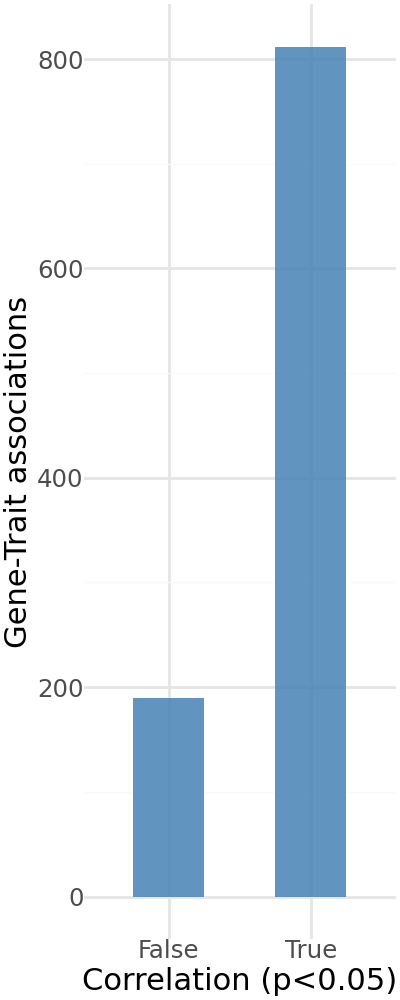

In [ ]:
(
    ggplot(gb_plof, aes(x='corr_nom_signif')) +
    geom_histogram(bins=3, fill='steelblue', alpha=0.85) +
    theme_minimal() +
    labs(x='Correlation (p<0.05)', y='Gene-Trait associations') +
    theme(figure_size=(2, 5))
)

In [40]:
gb_plof.filter(pl.col('sign_agreement')!=1)

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64,bool
"""G6PC1""",17,"""ENSG00000131482""",0.000904,357443,-0.110167,0.0223225,24.3567,6.09665,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000131482""",8.0048e-7,0.013907,268,24,0.030656,"[291, 180, … 1]",27,0.024152,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.100746,0.394017,0.693884,false
"""E2F8""",11,"""ENSG00000129173""",0.000341,353457,-0.25405,0.0511269,24.691,6.17201,"""red_blood_cell_erythrocyte_cou…","""quantitative""",true,17357,true,"""red_blood_cell_erythrocyte_cou…","""ENSG00000129173""",6.7296e-7,0.011691,549,36,0.102538,"[162, 17, … 1]",37,0.09162,"[162, 17, … 1]","""chr11:19224693:G:A""",162,0.067395,2.151874,0.031844,false
"""TCIM""",8,"""ENSG00000176907""",0.000431,353457,0.233324,0.045455,26.3486,6.54512,"""red_blood_cell_erythrocyte_cou…","""quantitative""",true,17357,true,"""red_blood_cell_erythrocyte_cou…","""ENSG00000176907""",2.8502e-7,0.004952,98,5,-0.080718,"[244, 4, … 1]",11,0.05067,"[244, 39, … 1]","""chr8:40153614:GAC:G""",244,0.112245,0.497104,0.620253,false
"""DGAT2""",11,"""ENSG00000062282""",0.000772,316079,-0.197942,0.0387264,26.1254,6.49492,"""apolipoprotein_a""","""quantitative""",true,17276,true,"""apolipoprotein_a_int""","""ENSG00000062282""",3.1995e-7,0.005558,275,23,0.08577,"[429, 14, … 1]",24,0.090448,"[429, 14, … 1]","""chr11:75798272:C:A""",429,0.087273,1.500598,0.134615,false
"""G6PC1""",17,"""ENSG00000131482""",0.000903,357549,-0.10635,0.022432,22.4771,5.67231,"""whole_body_water_mass""","""quantitative""",true,17356,true,"""whole_body_water_mass_int""","""ENSG00000131482""",0.000002,0.036946,268,24,0.041975,"[291, 180, … 1]",27,0.034718,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.100746,0.566572,0.571483,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CST9L""",20,"""ENSG00000101435""",0.000215,347208,-0.353916,0.0703426,25.3142,6.31236,"""cystatin_c""","""quantitative""",true,17342,true,"""cystatin_c_int""","""ENSG00000101435""",4.8712e-7,0.008463,111,10,0.158215,"[6, 3, … 1]",12,0.241029,"[6, 3, … 1]","""chr20:23566070:TAC:T""",6,0.108108,2.592862,0.010824,false
"""G6PC1""",17,"""ENSG00000131482""",0.000903,357518,-0.105163,0.0223804,22.0798,5.58245,"""whole_body_fatfree_mass""","""quantitative""",true,17356,true,"""whole_body_fatfree_mass_int""","""ENSG00000131482""",0.000003,0.045439,268,24,0.027743,"[291, 180, … 1]",27,0.021048,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.100746,0.343364,0.731596,false
"""DENND2C""",1,"""ENSG00000175984""",0.000426,353450,-0.313816,0.0526823,35.4831,8.5896,"""platelet_distribution_width""","""quantitative""",true,17357,true,"""platelet_distribution_width_in…","""ENSG00000175984""",2.5728e-9,0.000045,646,60,0.004214,"[86, 56, … 1]",65,0.007525,"[86, 56, … 1]","""chr1:114600941:TTC:T""",86,0.100619,0.19097,0.848609,false


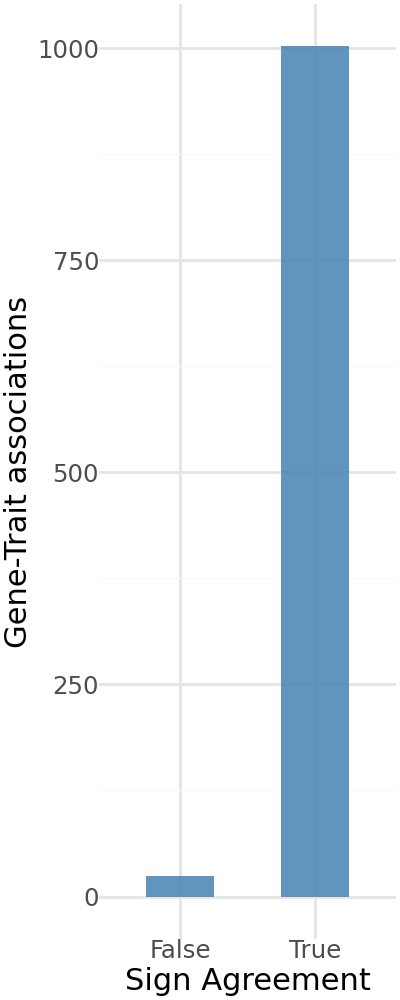

In [61]:
(
    ggplot(gb_plof, aes(x='sign_agreement')) +
    geom_histogram(bins=3, fill='steelblue', alpha=0.85) +
    theme_minimal() +
    labs(x='Sign Agreement', y='Gene-Trait associations') +
    theme(figure_size=(2, 5))
)

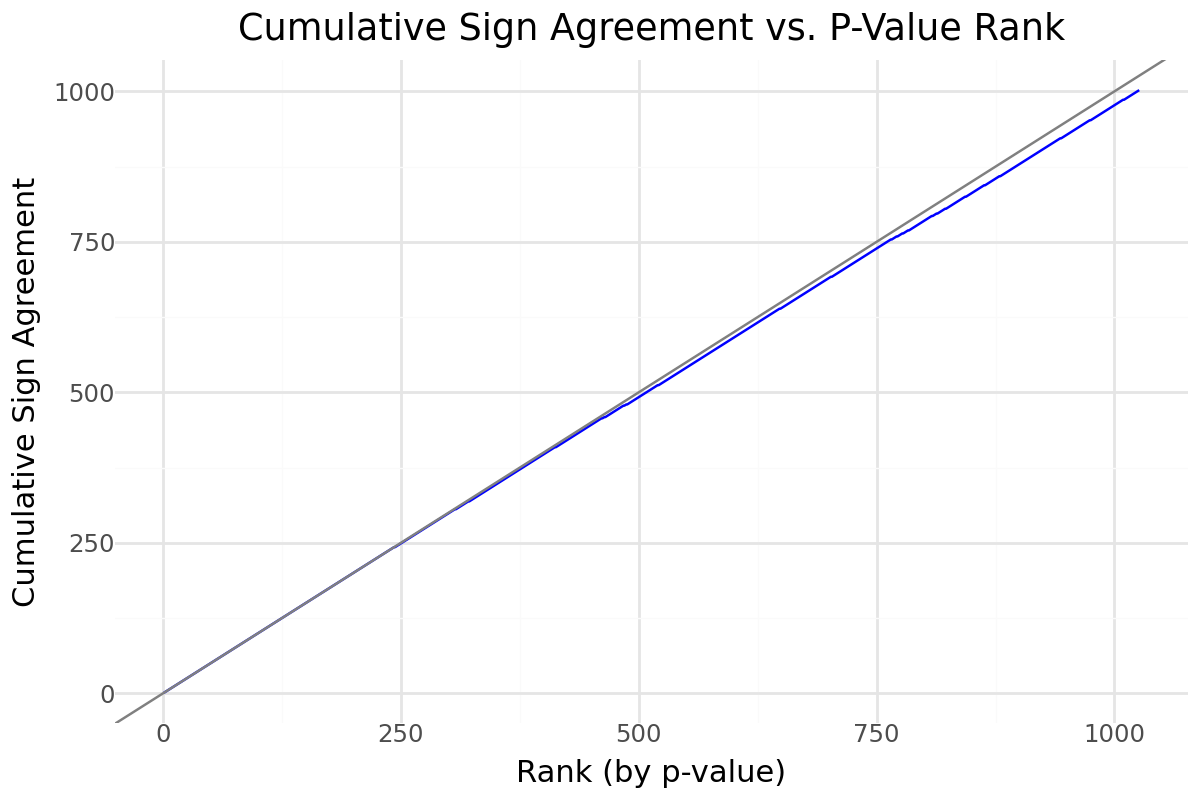

In [48]:
# prepare data
agg_df = (
    gb_plof
    # .select(['min_pvalue_skato', 'sign_agreement'])
    .select(['rvat_pval', 'sign_agreement'])
    .drop_nulls()
    # .sort('min_pvalue_skato')
    .sort('rvat_pval')
    .with_columns(
        rank = pl.int_range(1, pl.len() + 1),
        cum_agreement = pl.col('sign_agreement').cast(pl.Int32).cum_sum()
    )
)

(
    ggplot(agg_df, aes(x='rank', y='cum_agreement')) +
    geom_line(color='blue') +
    geom_abline(color='gray') +
    labs(
        x='Rank (by p-value)',
        y='Cumulative Sign Agreement',
        title='Cumulative Sign Agreement vs. P-Value Rank'
    ) +
    theme_minimal() +
    theme(figure_size=(6, 4))
)

### Investigate associations with opposite sign

In [50]:
ws_corr = gb_plof.filter(pl.col('sign_agreement')==0).sort('rvat_pval')
ws_corr

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,rvat_pval,p_adj_bonf,n_variants_nonull,n_loftee_variants,loftee_corr,n_individuals_loftee,n_plof_variants,plof_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,u64,i64,f32,list[u32],i64,f64,list[u32],str,u32,f64,f64,f64,bool
"""E2F8""",11,"""ENSG00000129173""",0.000341,353456,0.438625,0.0575771,58.0346,13.5891,"""mean_corpuscular_volume""","""quantitative""",true,17357,true,"""mean_corpuscular_volume_int""","""ENSG00000129173""",2.5757e-14,4.4748e-10,549,36,-0.086486,"[162, 17, … 1]",37,-0.082958,"[162, 17, … 1]","""chr11:19224693:G:A""",162,0.067395,-1.946944,0.052053,false
"""E2F8""",11,"""ENSG00000129173""",0.0003451,347731,0.414807,0.0595382,48.5401,11.49,"""mean_reticulocyte_volume""","""quantitative""",true,17340,true,"""mean_reticulocyte_volume_int""","""ENSG00000129173""",3.2359e-12,5.6218e-8,546,36,-0.088144,"[161, 17, … 1]",37,-0.08088,"[161, 17, … 1]","""chr11:19224693:G:A""",161,0.067766,-1.892619,0.058939,false
"""E2F8""",11,"""ENSG00000129173""",0.000341,353454,0.392997,0.0573158,47.0142,11.152,"""mean_corpuscular_haemoglobin""","""quantitative""",true,17357,true,"""mean_corpuscular_haemoglobin_i…","""ENSG00000129173""",7.0469e-12,1.2243e-7,549,36,-0.107385,"[162, 17, … 1]",37,-0.105305,"[162, 17, … 1]","""chr11:19224693:G:A""",162,0.067395,-2.476647,0.013564,false
"""E2F8""",11,"""ENSG00000129173""",0.0003451,347731,0.375388,0.0596476,39.6073,9.50791,"""mean_sphered_cell_volume""","""quantitative""",true,17340,true,"""mean_sphered_cell_volume_int""","""ENSG00000129173""",3.1052e-10,0.000005,546,36,-0.084464,"[161, 17, … 1]",37,-0.079379,"[161, 17, … 1]","""chr11:19224693:G:A""",161,0.067766,-1.857285,0.063811,false
"""RHAG""",6,"""ENSG00000112077""",0.000259,345812,0.356283,0.0586943,36.8466,8.89347,"""total_bilirubin""","""quantitative""",true,17336,true,"""total_bilirubin_int""","""ENSG00000112077""",1.2780e-9,0.000022,319,17,-0.01666,"[155, 5, … 1]",17,-0.01666,"[155, 5, … 1]","""chr6:49636655:C:T""",155,0.053292,-0.296667,0.766915,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""G6PC1""",17,"""ENSG00000131482""",0.000904,357443,-0.110167,0.0223225,24.3567,6.09665,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000131482""",8.0048e-7,0.013907,268,24,0.030656,"[291, 180, … 1]",27,0.024152,"[291, 180, … 1]","""chr17:42911391:C:T""",291,0.100746,0.394017,0.693884,false
"""MROH2A""",2,"""ENSG00000185038""",0.002055,295389,-0.13305,0.0271235,24.0623,6.03028,"""direct_bilirubin""","""quantitative""",true,17227,true,"""direct_bilirubin_int""","""ENSG00000185038""",9.3265e-7,0.016203,1348,104,0.024869,"[407, 227, … 1]",106,0.014042,"[407, 227, … 1]","""chr2:233811925:C:T""",407,0.078635,0.51522,0.606484,false
"""NIM1K""",5,"""ENSG00000177453""",0.001111,363104,-0.098204,0.0205134,22.9183,5.77202,"""standing_height""","""quantitative""",true,17372,true,"""standing_height_int""","""ENSG00000177453""",0.000002,0.029367,357,31,0.004353,"[678, 15, … 1]",33,0.022369,"[678, 18, … 1]","""chr5:43277223:AG:A""",678,0.092437,0.421565,0.673598,false


In [20]:
ws_corr.with_columns(
    eff_delta = pl.col('loftee_corr') - pl.col('beta')
).sort('eff_delta', descending=True)

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,loftee_corr,n_individuals_plof,plof_prop,t_stat,p_value,sign_agreement,eff_delta
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,list[u32],f64,f64,f64,bool,f64
"""ENSG00000101435""","""CST9L""","""cystatin_c_int""","""continuous""","""pLoF""",2.1518e-10,5.4183e-11,-0.353916,111,10,111,0.158215,"[6, 3, … 1]",0.09009,1.672885,0.097218,false,0.512131
"""ENSG00000129173""","""E2F8""","""red_blood_cell_erythrocyte_cou…","""continuous""","""pLoF""",8.6520e-14,1.3881e-10,-0.25405,549,36,549,0.102538,"[162, 17, … 1]",0.065574,2.410867,0.016243,false,0.356588
"""ENSG00000175984""","""DENND2C""","""platelet_distribution_width_in…","""continuous""","""pLoF""",4.0195e-8,4.7981e-8,-0.313816,646,60,646,0.004214,"[86, 56, … 1]",0.092879,0.106931,0.914877,false,0.31803
"""ENSG00000158747""","""NBL1""","""alkaline_phosphatase_int""","""continuous""","""pLoF""",3.2774e-10,0.000903,-0.288981,155,19,155,0.0236,"[171, 48, … 1]",0.122581,0.292002,0.77068,false,0.312581
"""ENSG00000062282""","""DGAT2""","""apolipoprotein_a_int""","""continuous""","""pLoF""",2.8753e-8,3.7061e-8,-0.197942,275,23,275,0.08577,"[429, 14, … 1]",0.083636,1.422389,0.156055,false,0.283712
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""total_bilirubin_int""","""continuous""","""pLoF""",1.3895e-11,5.0076e-11,0.356283,319,17,319,-0.01666,"[155, 5, … 1]",0.053292,-0.296667,0.766915,false,-0.372943
"""ENSG00000129173""","""E2F8""","""mean_sphered_cell_volume_int""","""continuous""","""pLoF""",3.3169e-20,4.6260e-14,0.375388,546,36,546,-0.084464,"[161, 17, … 1]",0.065934,-1.977094,0.048536,false,-0.459852
"""ENSG00000129173""","""E2F8""","""mean_corpuscular_haemoglobin_i…","""continuous""","""pLoF""",1.0703e-24,6.2092e-15,0.392997,549,36,549,-0.107385,"[162, 17, … 1]",0.065574,-2.526123,0.011814,false,-0.500382


In [ ]:
ws_genes = ws_corr['gene_name'].value_counts().join(ws_corr[['gene_name', 'n_variants', 'n_plof_variants', 'plof_prop']], on='gene_name').unique().sort('count', descending=True)
ws_genes

gene_name,count,n_variants,n_plof,plof_prop
str,u64,u64,i64,f64
"""GPR151""",11,339,29,0.085546
"""GPR151""",11,340,29,0.085294
"""E2F8""",5,546,36,0.065934
"""PACC1""",5,275,44,0.16
"""PACC1""",5,277,45,0.162455
…,…,…,…,…
"""SLC7A9""",1,402,31,0.077114
"""ME1""",1,335,37,0.110448
"""DENND2C""",1,646,60,0.092879


In [24]:
ws_corr.sort('Pvalue_Burden').head(10)

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,loftee_corr,n_individuals_plof,plof_prop,t_stat,p_value,sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,list[u32],f64,f64,f64,bool
"""ENSG00000112499""","""SLC22A2""","""lipoprotein_a_int""","""continuous""","""pLoF""",2.1950e-235,8.2294e-202,-0.102393,420,34,420,0.019285,"[674, 12, … 1]",0.080952,0.394354,0.693521,false
"""ENSG00000181284""","""TMEM102""","""shbg_int""","""continuous""","""pLoF""",1.8784e-65,8.9570e-59,0.0733701,387,27,387,-0.055731,"[99, 39, … 1]",0.069767,-1.095222,0.274104,false
"""ENSG00000152254""","""G6PC2""","""glucose_int""","""continuous""","""pLoF""",5.2530e-39,1.2336e-37,-0.125937,275,32,275,0.0685,"[69, 42, … 1]",0.116364,1.134476,0.25759,false
"""ENSG00000100024""","""UPB1""","""gamma_glutamyltransferase_int""","""continuous""","""pLoF""",2.1815e-39,5.4291e-30,0.0426767,352,46,352,-0.137077,"[148, 77, … 1]",0.130682,-2.588919,0.010029,false
"""ENSG00000168065""","""SLC22A11""","""urate_int""","""continuous""","""pLoF""",1.7850e-20,2.5501e-21,0.0904605,464,27,464,-0.049946,"[9, 5, … 1]",0.05819,-1.074896,0.282982,false
"""ENSG00000112787""","""FBRSL1""","""lymphocyte_count_int""","""continuous""","""pLoF""",2.1526e-21,1.4091e-19,-0.025216,1244,58,1244,0.097923,"[397, 36, … 1]",0.046624,3.467683,0.000543,false
"""ENSG00000112787""","""FBRSL1""","""monocyte_count_int""","""continuous""","""pLoF""",1.6771e-20,7.8466e-19,-0.008473,1244,58,1244,0.02718,"[397, 36, … 1]",0.046624,0.958241,0.338128,false
"""ENSG00000129173""","""E2F8""","""mean_corpuscular_volume_int""","""continuous""","""pLoF""",3.3250e-29,4.7070e-18,0.438625,549,36,549,-0.086486,"[162, 17, … 1]",0.065574,-2.030337,0.042806,false
"""ENSG00000129173""","""E2F8""","""mean_reticulocyte_volume_int""","""continuous""","""pLoF""",9.5111e-26,2.0467e-15,0.414807,546,36,546,-0.088144,"[161, 17, … 1]",0.065934,-2.063885,0.039502,false


## Single gene plots

### Single gene plot from appv

Pearson r: -0.055730946362018585, p-value: 0.2741039906398109


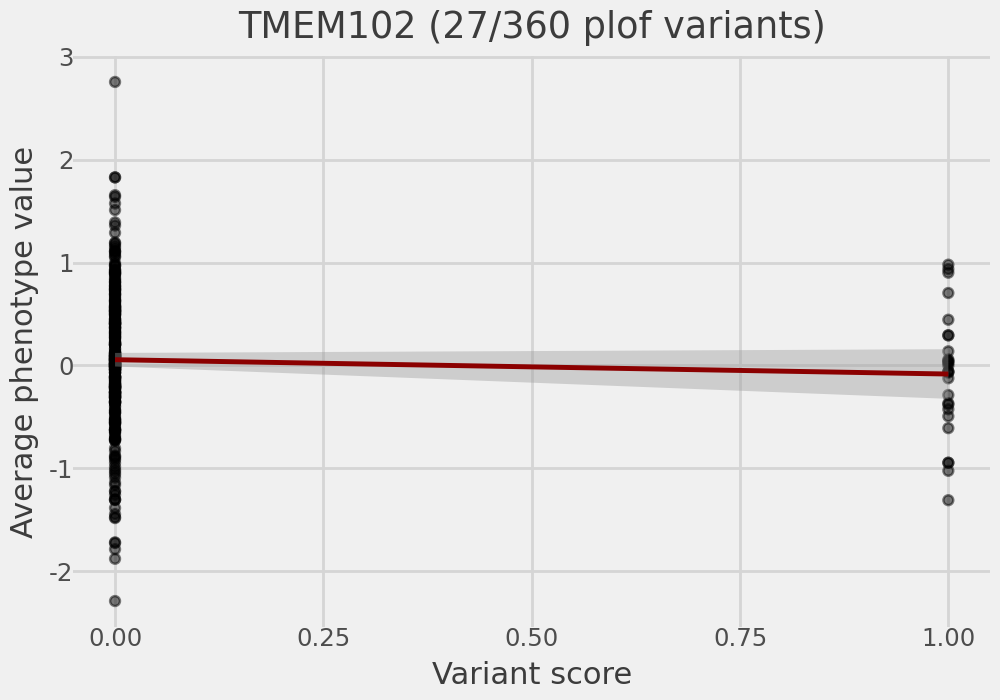

In [ ]:
method = 'pearson'
gene_name = 'TMEM102'
phenotype = 'shbg_int'
# gene_name = "APOC3"
# phenotype = "triglycerides_int"

alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc'])

# Filter your main dataframe
sc_df = alof_gp.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
).drop_nulls(subset=['loftee_hc', 'mean_pheno_value'])

lof0 = sc_df.filter(pl.col('loftee_hc') == 0).shape[0]
lof1 = sc_df.filter(pl.col('loftee_hc') == 1).shape[0]

# Check if enough data remains for calculation
if len(sc_df) >= 2:
    pearson_r, pearson_p = stats.pearsonr(
        sc_df['loftee_hc'], 
        sc_df['mean_pheno_value']
    )
else:
    pearson_r, pearson_p = np.nan, np.nan

print(f"Pearson r: {pearson_r}, p-value: {pearson_p}")
# Scatter plot
(
    ggplot(sc_df, aes(x='loftee_hc', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='Variant score',
        y="Average phenotype value",
        title=f"{gene_name} ({lof1}/{lof0} plof variants)"
    ) +
    theme(figure_size=(5, 3.5))
)

In [35]:
sc_df.filter(pl.col('loftee_hc') > 0).sort('n_individuals', descending=True)

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr17:7437171:G:GCCGGGAC""","""shbg_int""",99,-0.000088,0.824657,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7436621:AG:A""","""shbg_int""",39,0.02362,0.575144,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7436010:C:T""","""shbg_int""",36,-0.069378,0.706496,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7437452:CA:C""","""shbg_int""",29,0.035503,0.69818,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7436193:G:T""","""shbg_int""",17,0.294664,0.746762,"""ENSG00000181284""",1,"""TMEM102"""
…,…,…,…,…,…,…,…
"""chr17:7436816:G:GTC""","""shbg_int""",1,0.980366,null,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7436727:A:T""","""shbg_int""",1,-0.367286,null,"""ENSG00000181284""",1,"""TMEM102"""
"""chr17:7437328:T:A""","""shbg_int""",1,0.137866,null,"""ENSG00000181284""",1,"""TMEM102"""


### Single gene plot from burdens

In [36]:
from anngeno import AnnGeno

# --- 2. Read anngeno and get genotypes ---
ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)

gene_id = sc_df['region'].unique().item()
gdata = ag.get_many_regions([gene_id])[gene_id]

plof_burdens = pl.DataFrame({
    'individual': ag.samples,
    'burden': gdata['genotypes'].T @ gdata['annotations']['loftee_hc'].to_numpy()
})#.filter(pl.col('burden') < 2)

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

# --- 2. Read and merge data ---
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).select("IID", phenotype).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).select("IID", f"{phenotype}_prs").rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

# Join everything and collect into a pandas DataFrame for the regression
merged_pd = (
    pheno_lazy
    .join(prs_lazy, on="individual", how="inner")
    .join(cov_lazy, on="individual", how="inner")
    .drop_nulls()
    .drop_nans()
    .collect()
    .to_pandas()
)

# --- 3. Compute residuals for the single phenotype ---
# Define the dependent (y) and independent (X) variables
y = merged_pd[phenotype]
X = merged_pd[[f"{phenotype}_prs"] + cov_list]
X = sm.add_constant(X) # Add an intercept

# Fit the linear model and get the residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# --- 4. Create the final long-format DataFrame ---
# This is the final output, ready for plotting or debugging
p_df = pl.DataFrame({
    "individual": merged_pd["individual"].astype(str),
    "phenotype": phenotype,
    "pheno_value": residuals
})

# 4. Join with gene burdens
plot_gp_df = plof_burdens.join(p_df, on='individual', how='inner')
plot_gp_df

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


individual,burden,phenotype,pheno_value
str,i8,str,f64
"""3834985""",0,"""shbg_int""",-1.364295
"""1649233""",0,"""shbg_int""",0.303331
"""1160905""",0,"""shbg_int""",0.213983
"""5102203""",0,"""shbg_int""",-0.742139
"""1582656""",0,"""shbg_int""",-1.809705
…,…,…,…
"""5145210""",0,"""shbg_int""",0.122724
"""2864227""",0,"""shbg_int""",0.11729
"""3923515""",0,"""shbg_int""",-0.450632


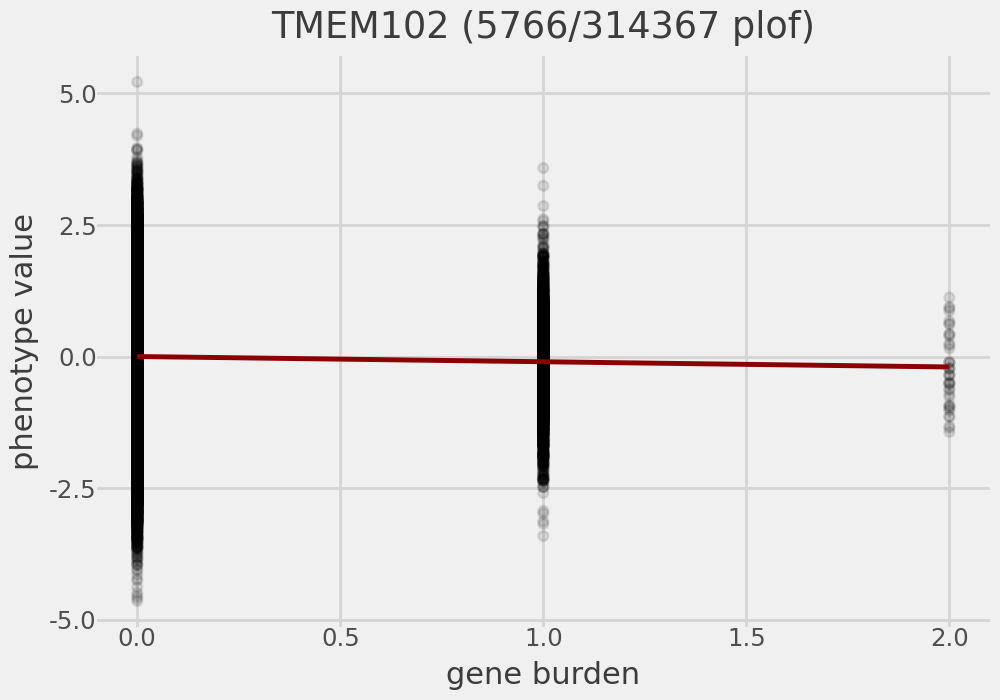

In [ ]:
(
    ggplot(plot_gp_df, aes(x='burden', y='pheno_value')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='gene burden',
        y="phenotype value",
        title=f"{gene_name} ({plot_gp_df['burden'].sum()}/{plot_gp_df.shape[0]} plof)"
    ) +
    theme(figure_size=(5, 3.5))
)

## Compare significances of correlation vs burden test

In [ ]:
from statsmodels.stats.multitest import multipletests

# The helper function to correct p-values
def apply_correction(pvals: pl.Series, method: str) -> pl.Series:
    if pvals.is_empty():
        return pvals
        
    _, pvals_corrected, _, _ = multipletests(
        pvals=pvals.to_numpy(),
        alpha=0.05,
        method=method
    )
    
    result = pl.Series(name=pvals.name, values=pvals_corrected, dtype=pl.Float64)
    return result

# Apply the correction using .map_batches() and .alias()
final_df = lofcorr_df.drop_nans().with_columns(
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='bonferroni'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bonf"),

    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='holm'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_holm"),
    
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='fdr_bh'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bh")
)
# View the final results
final_df

In [11]:
corr_signif = final_df.filter(pl.col('p_adj_bh') < 0.05)
corr_signif

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000152104""","""PTPN14""","""forced_expiratory_volume_in_1s…",729,44,729,-0.159325,-4.35145,0.000015,0.030905,0.030704,0.002145
"""ENSG00000179295""","""PTPN11""","""leg_fat_mass_left_int""",308,5,308,-0.202078,-3.609378,0.000358,0.720866,0.713201,0.030586
"""ENSG00000163359""","""COL6A3""","""arm_fatfree_mass_right_int""",2571,116,2571,-0.073541,-3.737593,0.00019,0.381772,0.376266,0.012726
"""ENSG00000075539""","""FRYL""","""arm_fatfree_mass_right_int""",1907,139,1907,-0.075831,-3.319278,0.00092,1.0,1.0,0.041092
"""ENSG00000162733""","""DDR2""","""hand_grip_strength_right_int""",515,19,515,-0.181892,-4.18965,0.000033,0.066151,0.065428,0.002876
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000122787""","""AKR1D1""","""body_mass_index_bmi_int""",225,25,225,0.256784,3.967648,0.000098,0.196796,0.19572,0.015328
"""ENSG00000143476""","""DTL""","""forced_expiratory_volume_in_1s…",365,33,365,-0.188202,-3.650975,0.0003,0.598947,0.58906,0.017477
"""ENSG00000171812""","""COL8A2""","""leg_predicted_mass_right_int""",627,28,627,0.148515,3.754509,0.00019,0.381863,0.375977,0.011933


In [32]:
plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    (10** -pl.col("neg_log10p")).alias("p_value")
).filter(
    (pl.col('trait_type') == 'quantitative')
)

plof_signif = plof.with_columns(
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='bonferroni'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bonf"),

    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='holm'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_holm"),
    
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='fdr_bh'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bh")
)

plof_signif = plof_signif.filter(pl.col('p_adj_bh') < 0.05)
plof_signif

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,f64,f64
"""TMEM240""",1,"""ENSG00000205090""",0.000008,357443,-0.891793,0.232211,14.749,3.91076,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000205090""",0.000123,1.0,1.0,0.044996
"""TRNAU1AP""",1,"""ENSG00000180098""",0.000141,357443,0.217876,0.056606,14.8148,3.9259,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000180098""",0.000119,1.0,1.0,0.04475
"""RPF1""",1,"""ENSG00000117133""",0.000373,357443,0.134444,0.0348228,14.9058,3.94687,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000117133""",0.000113,1.0,1.0,0.044579
"""PAPPA2""",1,"""ENSG00000116183""",0.000339,357443,-0.195409,0.0365758,28.5431,7.03793,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000116183""",9.1637e-8,0.00159,0.00159,0.000181
"""DTL""",1,"""ENSG00000143476""",0.000152,357443,-0.232484,0.0544889,18.2042,4.70236,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000143476""",0.00002,0.344421,0.343865,0.011877
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""VPS13A""",9,"""ENSG00000197969""",0.001064,347730,0.176348,0.0339876,26.9216,6.67392,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000197969""",2.1188e-7,0.003674,0.003671,0.000245
"""LRP5""",11,"""ENSG00000162337""",0.000231,114532,-0.794196,0.128014,38.4893,9.2592,"""heel_bone_mineral_density_bmd_…","""quantitative""",true,16041,true,"""heel_bone_mineral_density_bmd_…","""ENSG00000162337""",5.5055e-10,0.000009,0.000009,0.000004
"""CD63""",12,"""ENSG00000135404""",0.000266,114532,0.562505,0.119009,22.3405,5.64142,"""heel_bone_mineral_density_bmd_…","""quantitative""",true,16041,true,"""heel_bone_mineral_density_bmd_…","""ENSG00000135404""",0.000002,0.036628,0.036623,0.012209


In [15]:
# unique pairs in each table
gt_pairs = plof_signif.select(['gene_name', 'phenotype']).unique()
cs_pairs = corr_signif.select(['gene_name', 'phenotype']).unique()

# pairs present in gene_trait_df but missing in corr_signif
in_gt_not_cs = gt_pairs.join(cs_pairs, on=['gene_name', 'phenotype'], how='anti')

# pairs present in corr_signif but missing in gene_trait_df
in_cs_not_gt = cs_pairs.join(gt_pairs, on=['gene_name', 'phenotype'], how='anti')

# pairs present in both
in_both = gt_pairs.join(cs_pairs, on=['gene_name', 'phenotype'], how='inner')

# summary counts
print(f"unique pairs in gene_trait_df: {gt_pairs.shape[0]}")
print(f"unique pairs in corr_signif:   {cs_pairs.shape[0]}")
print(f"in gene_trait_df but not corr_signif: {in_gt_not_cs.shape[0]}")
print(f"in corr_signif but not gene_trait_df: {in_cs_not_gt.shape[0]}")
print(f"in both: {in_both.shape[0]}")

unique pairs in gene_trait_df: 2668
unique pairs in corr_signif:   3174
in gene_trait_df but not corr_signif: 1792
in corr_signif but not gene_trait_df: 2298
in both: 876


In [16]:
# show top 10 most significant pairs (by p-value) for each set
top_in_gt_not_cs = (
    in_gt_not_cs.join(
        plof_signif.select(['gene_name', 'phenotype', 'p_value']),
        on=['gene_name', 'phenotype'],
        how='left'
    )
    .sort('p_value', nulls_last=True)
    .head(10)
)
print("\nTop (gene_trait_df \\ corr_signif) sorted by p-value:")
print(top_in_gt_not_cs)

top_in_cs_not_gt = (
    in_cs_not_gt.join(
        final_df.select(['gene_name', 'phenotype', 'p_value']),
        on=['gene_name', 'phenotype'],
        how='left'
    )
    .sort('p_value', nulls_last=True)
    .head(10)
)
print("\nTop (corr_signif \\ gene_trait_df) sorted by p-value:")
print(top_in_cs_not_gt)


Top (gene_trait_df \ corr_signif) sorted by p-value:
shape: (10, 3)
┌───────────┬─────────────────────────────────┬─────────────┐
│ gene_name ┆ phenotype                       ┆ p_value     │
│ ---       ┆ ---                             ┆ ---         │
│ str       ┆ str                             ┆ f64         │
╞═══════════╪═════════════════════════════════╪═════════════╡
│ GP1BA     ┆ mean_platelet_thrombocyte_volu… ┆ 1.3183e-102 │
│ APOC3     ┆ triglycerides_int               ┆ 1.4441e-72  │
│ ANGPTL3   ┆ apolipoprotein_a_int            ┆ 2.3933e-56  │
│ GP1BB     ┆ mean_platelet_thrombocyte_volu… ┆ 4.4494e-55  │
│ IGFALS    ┆ igf1_int                        ┆ 9.4755e-52  │
│ ANGPTL3   ┆ cholesterol_int                 ┆ 2.2289e-49  │
│ RHAG      ┆ glycated_haemoglobin_hba1c_int  ┆ 1.0745e-45  │
│ RHAG      ┆ reticulocyte_percentage_int     ┆ 4.1581e-44  │
│ ASXL1     ┆ platelet_distribution_width_in… ┆ 6.7422e-44  │
│ LCORL     ┆ standing_height_int             ┆ 8.9023e-44  │
└

In [17]:
# If you want to inspect which genes contribute most to the differences:
print("\nTop genes with most pairs in gene_trait_df but missing in corr_signif:")
print(
    in_gt_not_cs.lazy()
    .group_by("gene_name")
    .agg(pl.count().alias("n_missing"))
    .sort("n_missing", descending=True)
    .head(10)
    .collect()
)

print("\nTop genes with most pairs in corr_signif but missing in gene_trait_df:")
print(
    in_cs_not_gt.lazy()
    .group_by("gene_name")
    .agg(pl.count().alias("n_missing"))
    .sort("n_missing", descending=True)
    .head(10)
    .collect()
)


Top genes with most pairs in gene_trait_df but missing in corr_signif:
shape: (10, 2)
┌───────────┬───────────┐
│ gene_name ┆ n_missing │
│ ---       ┆ ---       │
│ str       ┆ u64       │
╞═══════════╪═══════════╡
│ PDE3B     ┆ 46        │
│ G6PC1     ┆ 28        │
│ TTN       ┆ 26        │
│ LCORL     ┆ 24        │
│ BLTP1     ┆ 21        │
│ PTPRJ     ┆ 21        │
│ ASXL1     ┆ 20        │
│ GHRH      ┆ 18        │
│ CNPY2     ┆ 15        │
│ SLTM      ┆ 15        │
└───────────┴───────────┘

Top genes with most pairs in corr_signif but missing in gene_trait_df:
shape: (10, 2)
┌───────────┬───────────┐
│ gene_name ┆ n_missing │
│ ---       ┆ ---       │
│ str       ┆ u64       │
╞═══════════╪═══════════╡
│ C1QL4     ┆ 35        │
│ PKD1      ┆ 35        │
│ HECTD4    ┆ 31        │
│ DOT1L     ┆ 29        │
│ FRYL      ┆ 28        │
│ COL1A1    ┆ 27        │
│ TUT7      ┆ 27        │
│ USP47     ┆ 27        │
│ ARHGAP21  ┆ 26        │
│ EIF5A     ┆ 24        │
└───────────┴───────

/tmp/ipykernel_19878/3538324539.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
/tmp/ipykernel_19878/3538324539.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
